In [1]:
import ROOT
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus']=False
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import mplhep as hep
from sklearn.neighbors import KernelDensity

In [2]:
hep.style.use(hep.style.ATLAS)
plt.rcParams.update({
    'figure.figsize': (8, 6), 
    'figure.dpi': 150, 
    'figure.facecolor':'white',

    #font
    'font.size': 12, 
    'axes.titlesize': 14, 
    'axes.labelsize': 12,
    'xtick.labelsize':12,
    'ytick.labelsize':12,
    'legend.fontsize':12,
    'axes.linewidth':1.2,
    'axes.grid':False,
    # Ticks — ROOT-like: inward, 4-sided, with minor ticks
    'xtick.top'           : True,
    'ytick.right'         : True,
    'xtick.minor.visible' : True,
    'ytick.minor.visible' : True,
    'xtick.direction'     : 'in',
    'ytick.direction'     : 'in',
    'xtick.major.size'    : 6,
    'xtick.minor.size'    : 3,
    'ytick.major.size'    : 6,
    'ytick.minor.size'    : 3,
    'xtick.major.width'   : 1.2,
    'ytick.major.width'   : 1.2,

    # Lines & markers
    'lines.linewidth'     : 1.8,
    'lines.markersize'    : 5,

    # Legend
    'legend.frameon'      : False,
    
    # Saving
    'savefig.dpi'         : 300,
    'savefig.bbox'        : 'tight',
    'savefig.facecolor'   : 'white',
})
# --- Colorblind-friendly HEP palette ---
HEP_COLORS = [
    '#0077BB',   # blue
    '#EE3377',   # magenta
    '#009988',   # teal
    '#EE7733',   # orange
    '#AA3377',   # purple
    '#BBBBBB',   # grey  (backgrounds, MC)
]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=HEP_COLORS)

In [3]:
f_cos = ROOT.TFile.Open("cosmic_mergecoll.root", "READ")
f_nu = ROOT.TFile.Open("nu_mergecoll.root", "READ")
if not f_cos or f_cos.IsZombie() or not f_nu or f_nu.IsZombie():
    raise FileNotFoundError("Error File not found")
tree_cos = f_cos.Get("hitdQ/TATree")
tree_nu = f_nu.Get("hitdQ/TATree")
if not tree_cos or not tree_nu:
    raise ValueError("Error the branch not found")

In [5]:
def is_bde(ch):
    return 0<=int(ch)<=6143
def collect_bde_adc(tree):
    """This will return a flat list of addc Integral value"""
    adc_list = []
    n_events = tree.GetEntries()

    for i in range(n_events):
        tree.GetEntry(i)
        adcs = tree.adc_integral
        channel = tree.channel_peak
        if not adcs or not channel:
            continue
        for adc, ch in zip(adcs, channel):
            if is_bde(ch):
                adc_list.append(float(adc))
    return adc_list

In [6]:
cos_adc = collect_bde_adc(tree_cos)
nu_adc = collect_bde_adc(tree_nu)

In [19]:
#Efficiency calcualtion here, I am switching to calculating only BDE 
def calculate_eff(adc_list, thr_min=1e6,  n_thr=200):
    arr = np.array(adc_list)
    total = len(arr)
    print("Total number of TA", total)
    thresholds = np.linspace(thr_min, arr.max(), n_thr)
    eff = [100.0 * np.sum(arr>=t) / total for t in thresholds]
    return thresholds, eff


In [20]:
thr_cos, eff_cos = calculate_eff(cos_adc)
thr_nu, eff_nu = calculate_eff(nu_adc)
plt.style.use(hep.style.ATLAS)
TARGET = 8e6
idx_cos = np.argmin(np.abs(thr_cos - TARGET))
idx_nu  = np.argmin(np.abs(thr_nu  - TARGET))

print(f"\nEfficiency at {TARGET/1e6:.0f}M ADC threshold:")
print(f"  Cosmic    : {eff_cos[idx_cos]:.1f}%  (n={len(cos_adc)} TAs)")
print(f"  Nu+Cosmic : {eff_nu[idx_nu]:.1f}%   (n={len(nu_adc)} TAs)")

Total number of TA 1204
Total number of TA 1897

Efficiency at 8M ADC threshold:
  Cosmic    : 0.1%  (n=1204 TAs)
  Nu+Cosmic : 3.6%   (n=1897 TAs)


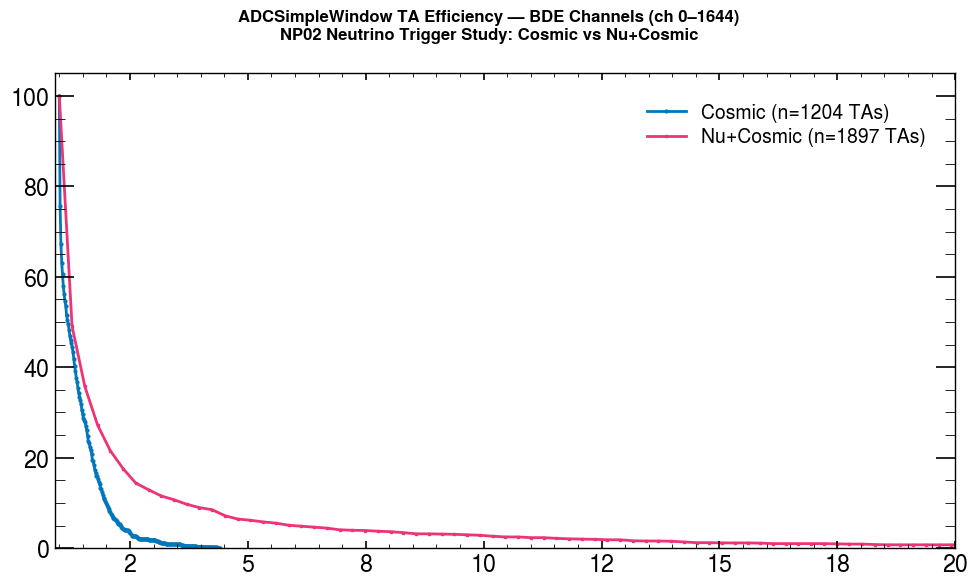

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

fig.suptitle(
    "ADCSimpleWindow TA Efficiency — BDE Channels (ch 0–1644)\n"
    "NP02 Neutrino Trigger Study: Cosmic vs Nu+Cosmic",
    fontsize=12, fontweight='bold'
)

ax.plot(thr_cos, eff_cos,
        color='#0077BB', linewidth=2, marker='o', markersize=2,
        label=f'Cosmic (n={len(cos_adc)} TAs)')

ax.plot(thr_nu, eff_nu,
        color='#EE3377', linewidth=2, marker='s', markersize=2,
        label=f'Nu+Cosmic (n={len(nu_adc)} TAs)')
ax.set_xlim(0.9e6, 20e6)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()